# The Evolving Pathogen Engine against a Static Barrier

In [ ]:
import random
import numpy as np
import pandas as pd
import itertools
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt


NUM_PATHOGENS = 1000                # Number Pathogens
GENERATIONS = 100
MUTATION_DETECTOR = 0.05            # Probability self bit flips
MUTATION_PATHOGEN = 0.5             # Probability self bit flips
THETA = 0.5                         # Immune pressure parameter


# Biological Abstraction Functions

In [29]:
def random_bitstring(n):
    return ''.join(random.choice('01') for _ in range(n))


# Self vs non-self similarity rule
def r_contiguous_match(s1, s2, r):
    """
    Return True if s1 and s2 share at least r contiguous matching symbols
    """
    count = 0
    for i in range(len(s1)):
        if s1[i] == s2[i]:
            count += 1
            if count >= r:
                return True
        else:
            count = 0
    return False

def mutate_bitstring(s, mutation_rate):
    bits = list(s)

    for i in range(len(bits)):
        if random.random() < mutation_rate:
            bits[i] = '1' if bits[i] == '0' else '0'

    return ''.join(bits)

# Detector Class

In [30]:
class Detector:
    def __init__(self, bitstring, r, MUTATION_DETECTOR):
        self.bitstring = bitstring
        self.r = r
        self.MUTATION_DETECTOR = MUTATION_DETECTOR
        self.fitness = 1.0

    def detect(self, pathogen):
        # Made deterministic: directly return if a match is found, no longer using DETECTION_SUCCESS
        return r_contiguous_match(self.bitstring, pathogen.bitstring, self.r)

# Pathogen Class

In [31]:
class Pathogen:

    def __init__(self, bitstring, THETA, MUTATION_PATHOGEN, ALPHA, l): # Added ALPHA parameter
        self.bitstring = bitstring
        self.THETA = THETA
        self.MUTATION_PATHOGEN = MUTATION_PATHOGEN
        self.ALPHA = ALPHA  # Weight for protein score (e.g., 0.2 means 20% weight on structure, 80% on evasion)
        self.l = l
        self.fitness = 0.0

    def protein_score(self):
        """
        Preserves pathogen structure: more 1s = better. 
        protein score = number of "1" / Number of bits 
        """
        return self.bitstring.count('1') / self.l

    def detection_score(self, detectors):
        """
        Less recognisable = higher score
        detection score = number of detections
        """
        if not detectors:
            return 0.0
        
        detections = sum(1 for d in detectors if d.detect(self))
        return detections / len(detectors)

    def evaluate_fitness(self, detectors):
        D = len(detectors)
        detection_ratio = self.detection_score(detectors)
        probability_evasion = np.exp(-self.THETA * (D / 1000.0)) # Scaled to prevent immediate absolute zero
        if probability_evasion > detection_ratio:
            evasion_component = probability_evasion
            protein_component = self.protein_score()
            # Blended fitness formula
            self.fitness = ((1 - self.ALPHA) * evasion_component) + (self.ALPHA * protein_component)
        else:
            self.fitness = 0.0 # Caught!
            
    # Mutation
    def mutate(self):
        self.bitstring = mutate_bitstring(self.bitstring, self.MUTATION_PATHOGEN)
    
    # Crossover
    def crossover(self, other):
        point = random.randint(1, self.l - 1)
        child_bitstring = (self.bitstring[:point] + other.bitstring[point:])

        # Inherit parameters from either parent
        theta = (self.THETA + other.THETA) / 2
        mutation_rate = (self.MUTATION_PATHOGEN + other.MUTATION_PATHOGEN) / 2
        
        # Average or inherit the alpha weight parameter
        alpha = (self.ALPHA + other.ALPHA) / 2

        return Pathogen(child_bitstring, theta, mutation_rate, alpha, self.l)
      
    def __repr__(self):
        return (f"Pathogen(bitstring='{self.bitstring}', fitness={self.fitness:.3f})")

# Negative Selection Algorithm

In [ ]:
# Negative Selection Algorithm

def generate_detectors(NUM_DETECTORS, l, R):

    detectors = []
    SELF = "0" * l   
       
    while len(detectors) < NUM_DETECTORS:
        # Random detectors are generated with a random R and Mutation Rate
        candidate = random_bitstring(l)
        # Negative Selection: detectors recognizing "SELF" are removed
        if not r_contiguous_match(candidate, SELF, R):
            detectors.append(Detector(candidate, R, MUTATION_DETECTOR))
    return detectors


def generate_pathogens(NUM_PATHOGENS, l, ALPHA):
    pathogens = []
    for _ in range(NUM_PATHOGENS):

        # start pathogen near all-ones
        s = ''.join(
            random.choice(['1', '1', '1', '0'])
            for _ in range(l)
        )
        pathogens.append(Pathogen(s, THETA, MUTATION_PATHOGEN, ALPHA, l))

    return pathogens


# Self Evolution (Genetic Algorithm)

In [ ]:
# Self Evolution (Genetic Algorithm) Pathogen

def evolve_pathogens(pathogens, detectors):

    # evaluate fitness
    for p in pathogens:
        p.evaluate_fitness(detectors)

    # sort pathogens based on fitness 
    pathogens.sort(key=lambda x: x.fitness, reverse=True) 

    # Elitism: it keeps only 50% of the best. (Natural Selection)
    survivors = pathogens[:NUM_PATHOGENS // 2]
    children = []

    while len(children) < NUM_PATHOGENS // 2:
        
        # Select random parent2
        parent1 = random.choice(survivors)
        parent2 = random.choice(survivors)

        # Crossover between parents 
        child = parent1.crossover(parent2)
        
        # Mutation
        child.mutate()

        children.append(child)

    return survivors + children


#  Self Evolution (Genetic Algorithm) Detectors

def evolve_detectors(detectors, pathogens):
    if not detectors: return []
    
    alive_detectors = []
    sample_size = min(10, len(pathogens))
    test_pathogens = random.sample(pathogens, sample_size)
    
    for d in detectors:
        # A detector survives if it catches at least one pathogen in the sample space
        if any(d.detect(p) for p in test_pathogens):
            alive_detectors.append(d)
            
    return alive_detectors
    

In [34]:
# Parameters for testing
l_values = [5, 10, 20]            
r_values = [2, 3, 8]
alpha_values = [0, 0.2, 0.5, 0.8, 1]
num_detectors_grid = [500, 2000] # Representative small vs. large immune systems
experimental_results = []
REPETITIONS = 3  # Run each configuration 3 times for statistical validation


def run_simulation(l, n_detectors, r, alpha, GENERATIONS):
    """
    Wraps your simulation logic. Returns the final performance metrics.
    Note: Ensure your Pathogen/Detector classes read these dynamic variables 
    instead of relying on hardcoded global variables!
    """
    
    detectors = generate_detectors(n_detectors, l, r)
    pathogens = generate_pathogens(NUM_PATHOGENS, l, alpha)
    
    for generation in range(GENERATIONS):
        pathogens = evolve_pathogens(pathogens, detectors)
        detectors = evolve_detectors(detectors, pathogens)
        if len(detectors) == 0:
            break  # Break early if immune system experiences absolute collapse
            
    # Calculate metric extractions at the final step
    if len(pathogens) == 0:
        final_avg_fitness = 0.0
        final_protein_score = 0.0
    else:
        final_avg_fitness = np.mean([p.fitness for p in pathogens])
        final_protein_score = np.mean([p.protein_score() for p in pathogens])
        
    detector_survival_rate = len(detectors) / n_detectors
    
    return final_avg_fitness, final_protein_score, detector_survival_rate

if __name__ == "__main__":
    experimental_results = []
    print("Beginning automated evaluation sweep...")

    # Iterate through every mathematical permutation of parameters
    for l, n_det, r, alpha in itertools.product(l_values, num_detectors_grid, r_values, alpha_values):
        
        # Enforce mathematical bound: threshold rule cannot exceed total string bits
        if r > l:
            continue
            
        print(f"Processing Config -> l: {l}, N: {n_det}, r: {r}, alpha: {alpha}")
        
        # Lists to gather statistical variance across repetitions
        rep_fitness = []
        rep_proteins = []
        rep_survival = []
        
        for rep in range(REPETITIONS):
            fit, prot, survival = run_simulation(l, n_det, r, alpha, GENERATIONS)
            rep_fitness.append(fit)
            rep_proteins.append(prot)
            rep_survival.append(survival)
            
        # Store clean means and statistical variations for report presentation
        experimental_results.append({
            "String Length (l)": l,
            "Initial Detectors (N)": n_det,
            "Matching Threshold (r)": r,
            "Structural Weight (alpha)": alpha,
            "Mean Pathogen Fitness": np.mean(rep_fitness),
            "Fitness StdDev": np.std(rep_fitness),
            "Mean Protein Score": np.mean(rep_proteins),
            "Protein StdDev": np.std(rep_proteins),
            "Mean Detector Survival Rate": np.mean(rep_survival)
        })

    # Save out structured spreadsheet data directly matching report criteria
    df = pd.DataFrame(experimental_results)
    df.to_csv("comprehensive_sweep_results.csv", index=False)
    print("\nSimulation process complete. Dataset exported to 'comprehensive_sweep_results.csv'.")
    
    # Showcase data head sample format
    print(df.head())

Beginning automated evaluation sweep...
Processing Config -> l: 5, N: 500, r: 2, alpha: 0
Processing Config -> l: 5, N: 500, r: 2, alpha: 0.2
Processing Config -> l: 5, N: 500, r: 2, alpha: 0.5
Processing Config -> l: 5, N: 500, r: 2, alpha: 0.8
Processing Config -> l: 5, N: 500, r: 2, alpha: 1
Processing Config -> l: 5, N: 500, r: 3, alpha: 0
Processing Config -> l: 5, N: 500, r: 3, alpha: 0.2
Processing Config -> l: 5, N: 500, r: 3, alpha: 0.5
Processing Config -> l: 5, N: 500, r: 3, alpha: 0.8
Processing Config -> l: 5, N: 500, r: 3, alpha: 1
Processing Config -> l: 5, N: 2000, r: 2, alpha: 0
Processing Config -> l: 5, N: 2000, r: 2, alpha: 0.2
Processing Config -> l: 5, N: 2000, r: 2, alpha: 0.5
Processing Config -> l: 5, N: 2000, r: 2, alpha: 0.8
Processing Config -> l: 5, N: 2000, r: 2, alpha: 1
Processing Config -> l: 5, N: 2000, r: 3, alpha: 0
Processing Config -> l: 5, N: 2000, r: 3, alpha: 0.2
Processing Config -> l: 5, N: 2000, r: 3, alpha: 0.5
Processing Config -> l: 5, N: 

# The Multi-Panel Grid Plot

This script creates a grid of plots separating small (N=500) vs. large (N=2000) immune systems across different string lengths (l), plotting the Pathogen Fitness against the Structural Weight (α).

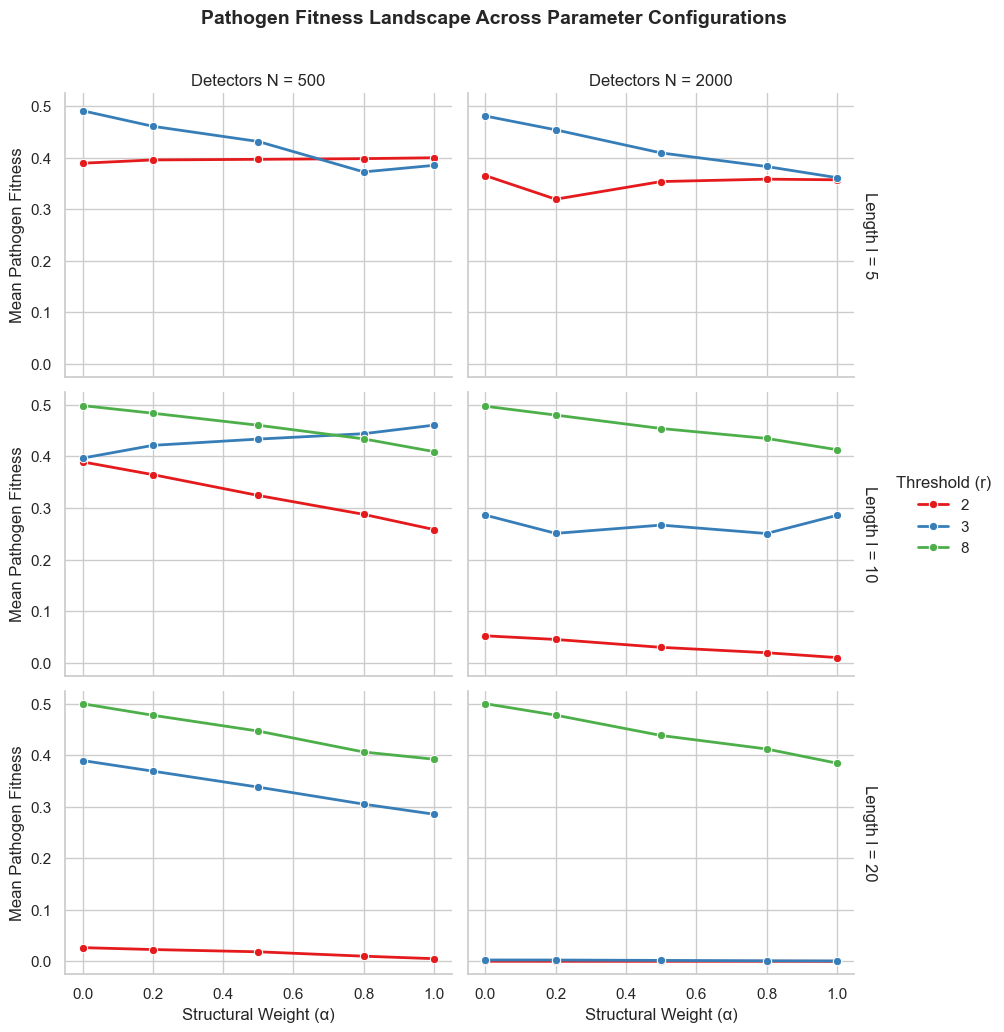

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the exported data
df = pd.read_csv("comprehensive_sweep_results.csv")

# Set up clean aesthetic styling for an academic report
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12})

# Create a FacetGrid (Rows = String Length, Columns = Initial Detectors)
g = sns.FacetGrid(
    df, 
    row="String Length (l)", 
    col="Initial Detectors (N)", 
    hue="Matching Threshold (r)", 
    palette="Set1", 
    margin_titles=True,
    sharey=True,
    height=3.5, 
    aspect=1.3
)

# Map a lineplot onto the grid with error bars representing the StdDev variance
g.map_dataframe(
    sns.lineplot, 
    x="Structural Weight (alpha)", 
    y="Mean Pathogen Fitness", 
    marker="o",
    linewidth=2
)

# Refine titles, axis labels, and layout bounds
g.set_axis_labels("Structural Weight (\u03b1)", "Mean Pathogen Fitness")
g.set_titles(row_template="Length l = {row_name}", col_template="Detectors N = {col_name}")
g.add_legend(title="Threshold (r)")

# Adjust layout spacing dynamically so headings don't overlap
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Pathogen Fitness Landscape Across Parameter Configurations", fontsize=14, weight='bold')

# Save the figure directly to a high-resolution image for your Word document
plt.savefig("pathogen_fitness_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# Tracking Immune Decay
To specifically highlight Experiment 1 (Systemic Collapse) on the detector side, use this quick script to isolate and plot how many detectors managed to survive the 100 generations under various thresholds.

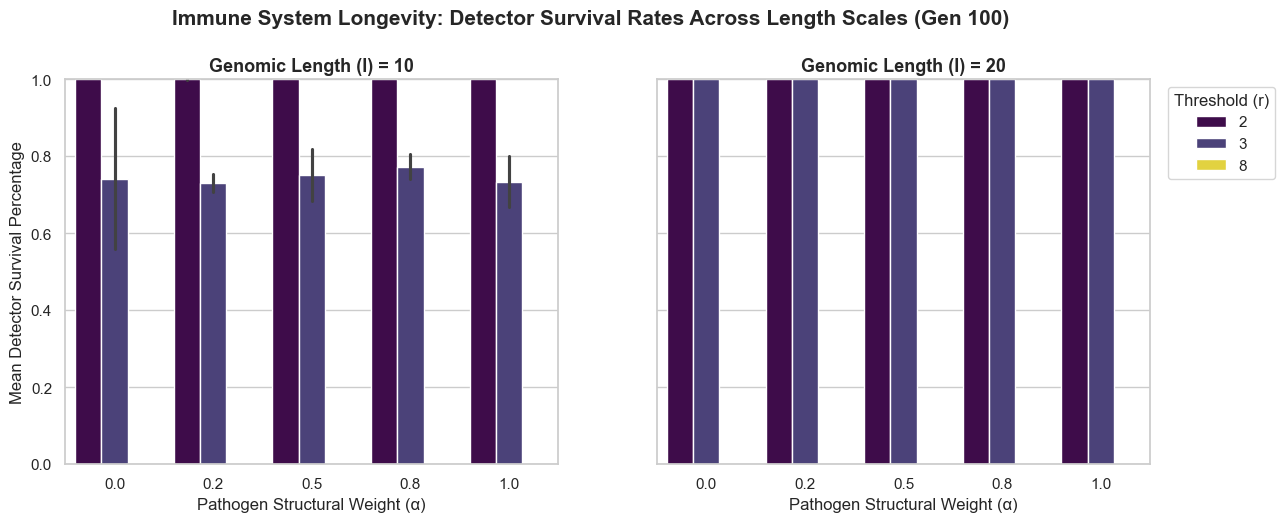

In [37]:
# Filter data to include only the lengths you want to compare
df_filtered = df[df["String Length (l)"].isin([10, 20])].copy()

# Set up clean academic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

# Create a two-panel subplot layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Define lengths to map to each subplot panel
lengths = [10, 20]

for i, l_val in enumerate(lengths):
    # Isolate data for the current panel's string length
    panel_data = df_filtered[df_filtered["String Length (l)"] == l_val]
    
    # Draw the bar chart on the specific axis panel
    sns.barplot(
        data=panel_data,
        x="Structural Weight (alpha)",
        y="Mean Detector Survival Rate",
        hue="Matching Threshold (r)",
        palette="viridis",
        ax=axes[i]
    )
    
    # Set titles and clean up labels for each individual panel
    axes[i].set_title(f"Genomic Length (l) = {l_val}", weight='bold')
    axes[i].set_xlabel("Pathogen Structural Weight (\u03b1)")
    axes[i].set_ylim(0, 1.0)
    
    # Remove individual legends to create a cleaner shared layout
    if i == 0:
        axes[i].set_ylabel("Mean Detector Survival Percentage")
        axes[i].get_legend().remove()
    else:
        axes[i].set_ylabel("") # Hide y-axis label on the second panel since it's shared
        # Position a single unified legend cleanly to the right of the plot
        axes[i].legend(title="Threshold (r)", loc="upper left", bbox_to_anchor=(1.02, 1))

# Add a comprehensive global title across both subplots
fig.suptitle("Immune System Longevity: Detector Survival Rates Across Length Scales (Gen 100)", 
             fontsize=15, weight='bold', y=1.02)

# 4. Save out as a crystal-clear chart for your document layout
plt.savefig("detector_survival_l10_vs_l20.png", dpi=300, bbox_inches='tight')
plt.show()